In [ ]:
import pandas as pd
import argparse
import numpy as np
import pymc as pm
import arviz as az
import statsmodels.formula.api as smf
from statsmodels.iolib.summary2 import summary_col
import ajr_causalpy_iv as ajr
import pytensor
import matplotlib.pyplot as plt


%load_ext autoreload
%autoreload 2


In [10]:
# Correct priors structure for loosening exclusion restriction
priors_delta = {
    "mus": [
        [0, 0, 0, 0, 0, 0],               # β_z  (intercept, slope on logem4)
        [0, 0, 0, 0, 0, 0, -0.4]
    ],
    "sigmas": [
        [1000, 1000, 1000, 1000, 1000, 1000],               # β_z block → normal priors with sd=1
        [1000, 1000, 1000, 1000, 1000, 1000, 1e-6]
    ],
    "eta": 2,                 # LKJ prior parameter
    "lkj_sd": 1,              # LKJ scale parameter
}
data_path = r"C:\Users\B375471\Downloads\Acemoglu_osv\colonial_origins\maketable4\maketable4.dta"
df_ajr = ajr.load_ajr_data(data_path, baseline_only=True)

# Run the model with priors_delta
iv_delta = ajr.run(
    data=df_ajr,  # Pass the filtered dataframe 
    priors=priors_delta, 
    draws=2000, 
    tune=1000, 
    chains=4, 
    cores=4, 
    loosen_exclusion=True,
    covariates=['asia', 'africa', 'other_cont', 'lat_abst'],
    netcdf_path="ajr_iv_delta_posterior5.nc"
)

Original dataset size: 163
After baseco == 1 filter: 64
After dropna: 64 observations
First-stage formula: avexpr ~ 1 + asia + africa + other_cont + lat_abst + logem4
Structural formula: logpgp95 ~ 1 + avexpr + asia + africa + other_cont + lat_abst + logem4


c:\Users\B375471\Anaconda3\envs\pymc_env\Lib\site-packages\causalpy\experiments\instrumental_variable.py:161: UserWarning: Warning. The treatment variable is not Binary.
                This is not necessarily a problem but it violates
                the assumption of a simple IV experiment.
                The coefficients should be interpreted appropriately.
  warnings.warn(
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta_t, beta_z, chol_cov]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 213 seconds.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.
Sampling: [likelihood]


Output()

                     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  \
beta_z[Intercept]   9.216  1.404   6.778   11.837      0.045    0.067   
beta_z[avexpr]      0.147  0.228  -0.238    0.585      0.007    0.011   
beta_z[asia]       -0.636  0.305  -1.198   -0.101      0.007    0.010   
beta_z[africa]     -0.608  0.239  -1.026   -0.136      0.005    0.006   
beta_z[other_cont] -0.084  0.563  -1.156    0.919      0.013    0.015   
beta_z[lat_abst]    0.562  0.964  -1.258    2.248      0.023    0.031   
beta_z[logem4]     -0.400  0.000  -0.400   -0.400      0.000    0.000   
beta_t[Intercept]   7.819  0.928   6.029    9.482      0.020    0.013   
beta_t[asia]        0.455  0.507  -0.493    1.407      0.007    0.006   
beta_t[africa]     -0.241  0.416  -1.003    0.548      0.006    0.004   
beta_t[other_cont]  1.034  0.855  -0.580    2.690      0.012    0.010   
beta_t[lat_abst]    1.935  1.417  -0.744    4.529      0.021    0.016   
beta_t[logem4]     -0.358  0.178  -0.688   -0.024  

array([[<Axes: title={'center': 'beta_z\nIntercept'}>,
        <Axes: title={'center': 'beta_z\navexpr'}>,
        <Axes: title={'center': 'beta_z\nasia'}>],
       [<Axes: title={'center': 'beta_z\nafrica'}>,
        <Axes: title={'center': 'beta_z\nother_cont'}>,
        <Axes: title={'center': 'beta_z\nlat_abst'}>],
       [<Axes: title={'center': 'beta_z\nlogem4'}>, <Axes: >, <Axes: >]],
      dtype=object)

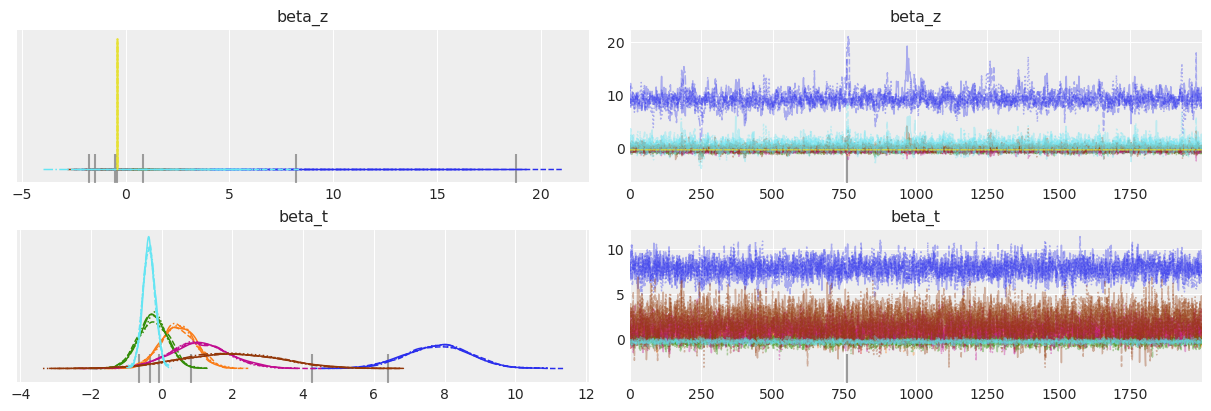

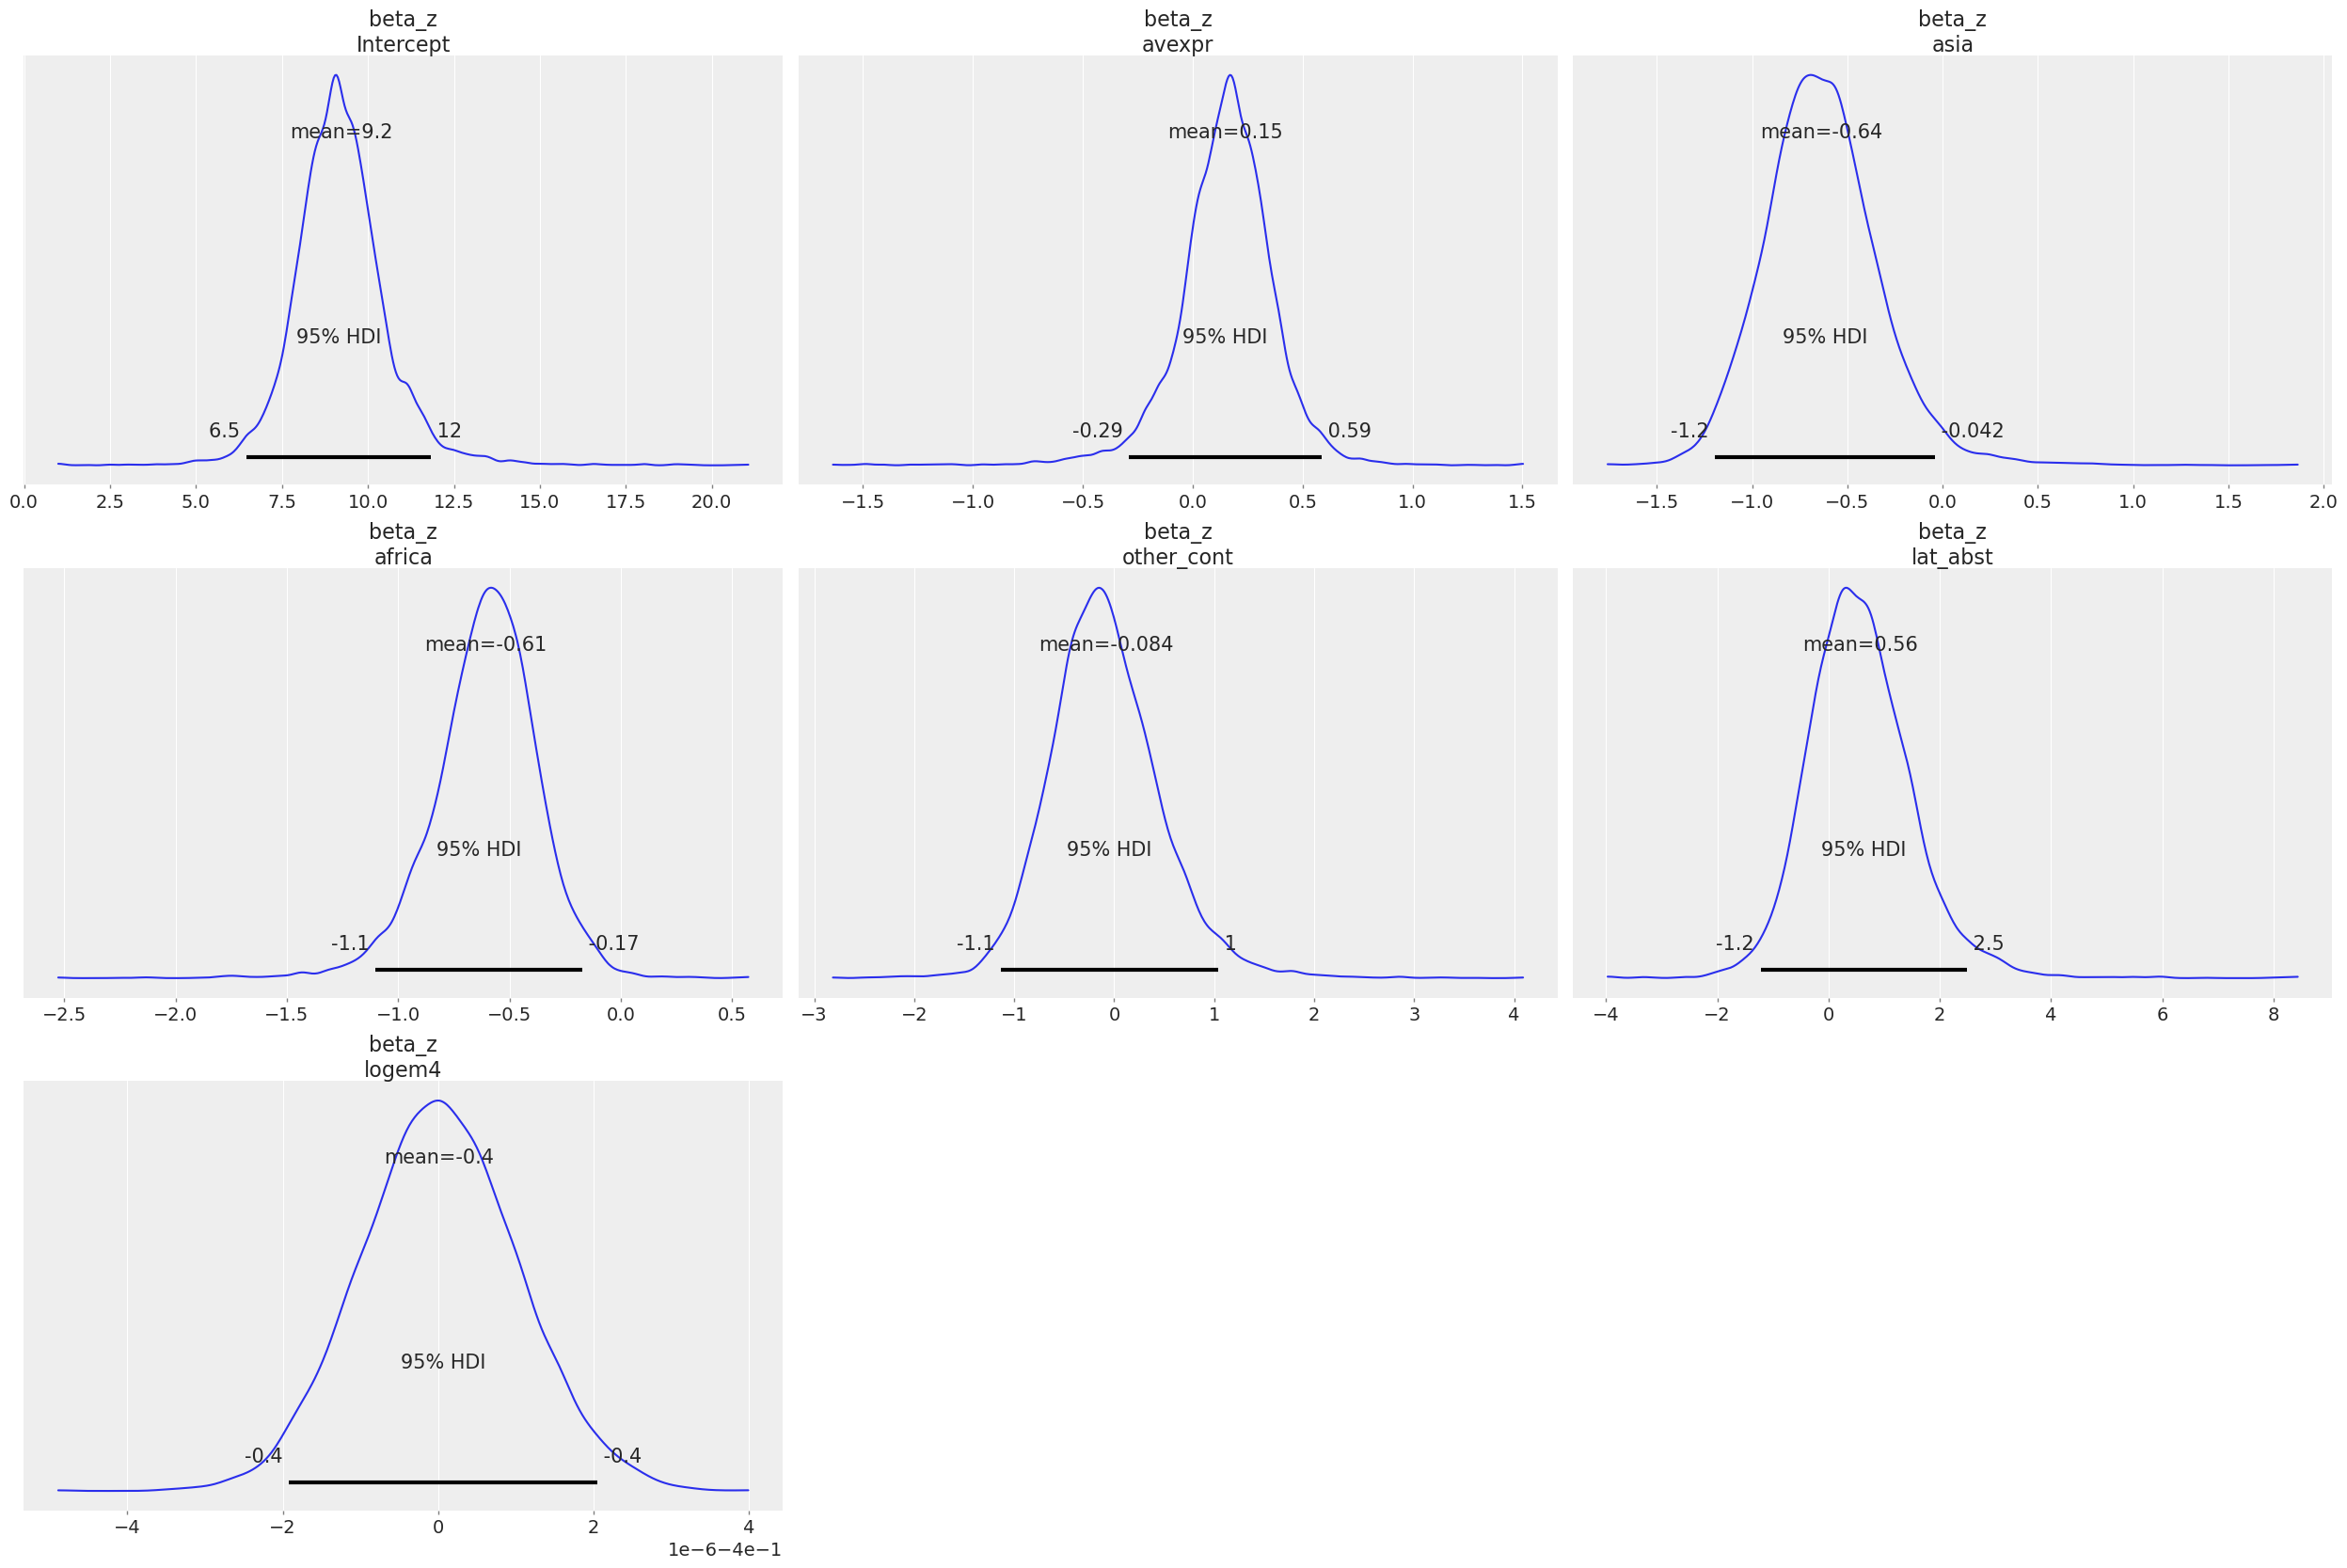

In [11]:
idata2 = az.from_netcdf("ajr_iv_delta_posterior5.nc")
az.plot_trace(idata2, var_names=["beta_z", "beta_t"])
az.plot_posterior(idata2, var_names=["beta_z"], hdi_prob=0.95)


Observed logpgp95 mean: 8.142
Predicted logpgp95 mean: 6.515
Observed logpgp95 std: 1.052
Predicted logpgp95 std: 0.943


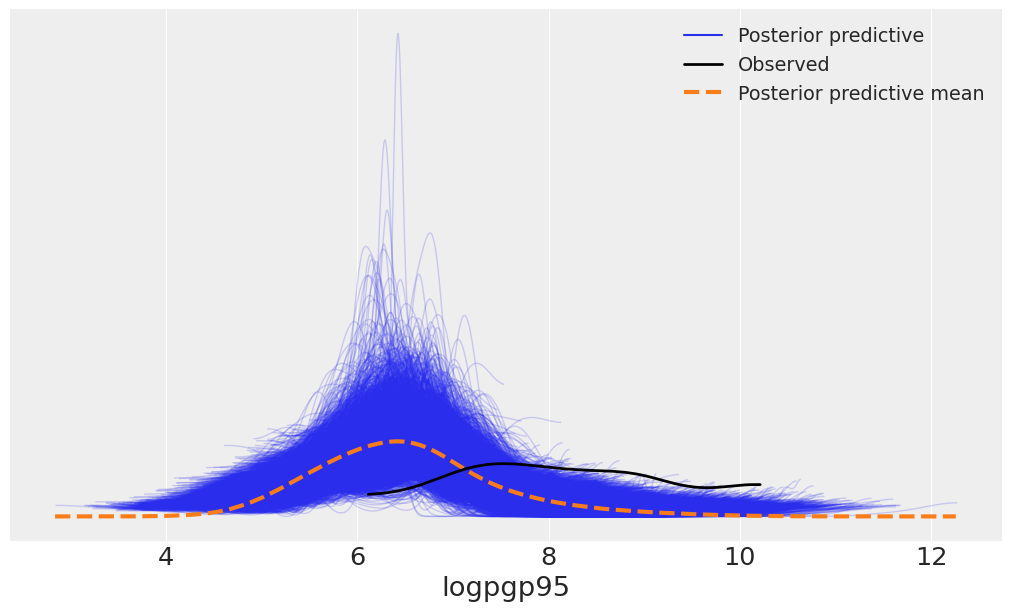

In [17]:
# Create proper posterior predictive data and use az.plot_ppc
import xarray as xr

# Extract structural equation predictions (logpgp95)
structural_preds = idata2.posterior['mu'].isel(mu_dim_1=1)  # logpgp95 predictions

# Get observed logpgp95 values
df_ajr = pd.read_stata(r"C:\Users\B375471\Downloads\Acemoglu_osv\colonial_origins\maketable4\maketable4.dta")
df_ajr = df_ajr.dropna(subset=['logem4', 'logpgp95', 'avexpr'])  # Same filtering as in ajr module
observed_logpgp95 = df_ajr['logpgp95'].values

# Add the logpgp95 predictions to posterior_predictive group
idata2.posterior_predictive = idata2.posterior_predictive.assign(
    logpgp95=structural_preds.rename(mu_dim_0='logpgp95_dim_0')
)

# Add the observed logpgp95 data to observed_data group
observed_da = xr.DataArray(
    observed_logpgp95, 
    dims=['logpgp95_dim_0'],
    coords={'logpgp95_dim_0': range(len(observed_logpgp95))}
)
idata2.observed_data = idata2.observed_data.assign(logpgp95=observed_da)

# Remove likelihood from both groups to avoid confusion
idata2.posterior_predictive = idata2.posterior_predictive.drop_vars('likelihood')
idata2.observed_data = idata2.observed_data.drop_vars('likelihood')

# Now use az.plot_ppc with proper data - specify only logpgp95
az.plot_ppc(
    idata2,
    data_pairs={"logpgp95": "logpgp95"},
    var_names=["logpgp95"],  # Only plot logpgp95, not likelihood
    figsize=(10, 6),
)

print(f"Observed logpgp95 mean: {observed_logpgp95.mean():.3f}")
print(f"Predicted logpgp95 mean: {structural_preds.mean().values:.3f}")
print(f"Observed logpgp95 std: {observed_logpgp95.std():.3f}")
print(f"Predicted logpgp95 std: {structural_preds.std().values:.3f}")

#### Simulations over delta-space

In [3]:
# ---- 1) Choose a grid of *fixed* δ values (violations of exclusion)
delta_grid = np.linspace(-0.4, 0, 7)   # tweak range/spacing as you like

# ---- 2) Decide which covariates you're using (must match your runs)
data_path = r"C:\Users\B375471\Downloads\Acemoglu_osv\colonial_origins\maketable4\maketable4.dta"
df_ajr = ajr.load_ajr_data(data_path, baseline_only=True)
covariates = ["lat_abst", "africa", "asia", "other_cont"]  # or None

# Helper to build priors that FIX δ at delta0 (others ≈ flat)
def priors_fix_delta(delta0, covariates=None):
    # infer lengths so the prior vectors match your spec
    p = len(covariates) if covariates else 0
    FLAT = 1e6                        # effectively non-informative

    # CORRECTED ORDERING: logem4 is LAST in both equations
    # First-stage: [intercept, covs..., logem4]
    mus_z = [0] + [0]*p + [0]         # logem4 coefficient gets mean 0 (not fixed)
    sig_z = [FLAT] + [FLAT]*p + [FLAT] # logem4 coefficient gets normal prior
    
    # Structural: [intercept, avexpr, covs..., logem4(delta)]
    mus_t = [0, 0] + [0]*p + [delta0] # delta (logem4 coeff) gets mean delta0
    sig_t = [FLAT, FLAT] + [FLAT]*p + [1e-6] # delta gets tiny sd (fixed)

    return {
        "mus":    [mus_z, mus_t],
        "sigmas": [sig_z, sig_t],
        "eta":    2,      # LKJ on residual corr (unchanged)
        "lkj_sd": 1,      # Exponential on sigmas (unchanged)
    }

# ---- 3) Run the grid and collect summaries
from tqdm import tqdm

fits, labels, rows = [], [], []
for i, d0 in enumerate(tqdm(delta_grid, desc="Delta grid simulation")):
    print(f"\n--- Running δ = {d0:+.2f} ({i+1}/{len(delta_grid)}) ---")
    
    pri = priors_fix_delta(d0, covariates=covariates)
    out = f"ajr_iv_fixdelta_{d0:+.2f}.nc"

    # Debug: Print prior structure
    print(f"Structural equation mus: {pri['mus'][0]}")  # beta_z is structural
    print(f"First-stage equation mus: {pri['mus'][1]}")  # beta_t is first-stage
    print(f"Expected: delta in first-stage = {d0} with tiny sd")

    iv, idata = ajr.run(
        data = df_ajr,
        loosen_exclusion=True,
        covariates=covariates,
        priors=pri,                   # δ fixed at d0
        draws=2000, tune=1000, chains=4, cores=4,
        target_accept=0.95,
        netcdf_path=out,
    )

    fits.append(idata); labels.append(f"δ={d0:+.2f}")
    
    # CORRECTED: Understanding the correct structure
    print("Beta_z coordinates (STRUCTURAL eq):", list(idata.posterior.coords['covariates'].values))
    print("Beta_t coordinates (FIRST-STAGE eq):", list(idata.posterior.coords['instruments'].values))
    
    covariates_list = list(idata.posterior.coords['covariates'].values)
    instruments_list = list(idata.posterior.coords['instruments'].values)
    
    # Find avexpr coefficient in STRUCTURAL equation (beta_z)
    try:
        avexpr_idx = covariates_list.index('avexpr')
    except ValueError:
        # If not found by name, assume it's at index 1 (after intercept)
        avexpr_idx = 1
        print(f"Warning: 'avexpr' not found in covariates, using index 1")
    
    # Find logem4 coefficient in FIRST-STAGE equation (beta_t) 
    try:
        logem4_idx = instruments_list.index('logem4')
    except ValueError:
        # If not found by name, use last index
        logem4_idx = -1
        print(f"Warning: 'logem4' not found in instruments, using last index")
    
    # Extract coefficients from CORRECT equations
    avexpr_coeff = idata.posterior["beta_z"].isel(covariates=avexpr_idx)  # STRUCTURAL: avexpr effect on logpgp95
    delta_coeff = idata.posterior["beta_z"].isel(covariates=logem4_idx)   # FIRST-STAGE: delta (logem4 effect on avexpr)
    
    avexpr_mean = float(avexpr_coeff.mean())
    delta_mean = float(delta_coeff.mean())
    
    # FIXED: HDI for avexpr coefficient using numpy percentiles as fallback
    try:
        avexpr_hdi = az.hdi(avexpr_coeff)
        print(f"HDI type: {type(avexpr_hdi)}")
        print(f"HDI structure: {avexpr_hdi}")
        
        # Try different extraction methods
        if hasattr(avexpr_hdi, 'data_vars'):
            # It's a Dataset
            var_name = list(avexpr_hdi.data_vars.keys())[0]
            hdi_array = avexpr_hdi[var_name].values
            hdi_low = float(hdi_array[0])
            hdi_high = float(hdi_array[1])
        else:
            # It's a DataArray
            hdi_array = avexpr_hdi.values
            hdi_low = float(hdi_array[0])
            hdi_high = float(hdi_array[1])
            
    except Exception as e:
        print(f"HDI extraction failed: {e}")
        # Fallback to manual percentiles
        avexpr_samples = avexpr_coeff.values.flatten()
        hdi_low = float(np.percentile(avexpr_samples, 2.5))
        hdi_high = float(np.percentile(avexpr_samples, 97.5))
    
    rows.append({
        "delta_fixed": d0,
        "delta_actual_mean": delta_mean,  # Should be close to d0
        "avexpr_causal_effect": avexpr_mean,  # This is the causal effect of institutions
        "avexpr_hdi_low": hdi_low,
        "avexpr_hdi_high": hdi_high,
        "delta_sd_used": 1e-6,
        "file": out
    })
    
    print(f"✓ δ fixed at {d0:+.2f}, actual mean: {delta_mean:+.3f}")
    print(f"  Avexpr causal effect: {avexpr_mean:.3f}")
    print(f"  HDI: [{hdi_low:.3f}, {hdi_high:.3f}]")
    print(f"  Available covariates (beta_z): {covariates_list}")
    print(f"  Available instruments (beta_t): {instruments_list}")
    print(f"  Used avexpr_idx={avexpr_idx}, logem4_idx={logem4_idx}")

summary = pd.DataFrame(rows).sort_values("delta_fixed")
print("\n=== SUMMARY TABLE ===")
summary

Original dataset size: 163
After baseco == 1 filter: 64
After dropna: 64 observations


Delta grid simulation:   0%|          | 0/7 [00:00<?, ?it/s]


--- Running δ = -0.40 (1/7) ---
Structural equation mus: [0, 0, 0, 0, 0, 0]
First-stage equation mus: [0, 0, 0, 0, 0, 0, np.float64(-0.4)]
Expected: delta in first-stage = -0.4 with tiny sd
First-stage formula: avexpr ~ 1 + lat_abst + africa + asia + other_cont + logem4
Structural formula: logpgp95 ~ 1 + avexpr + lat_abst + africa + asia + other_cont + logem4


c:\Users\B375471\Anaconda3\envs\pymc_env\Lib\site-packages\causalpy\experiments\instrumental_variable.py:161: UserWarning: Warning. The treatment variable is not Binary.
                This is not necessarily a problem but it violates
                the assumption of a simple IV experiment.
                The coefficients should be interpreted appropriately.
  warnings.warn(
Initializing NUTS using jitter+adapt_diag...
c:\Users\B375471\Anaconda3\envs\pymc_env\Lib\site-packages\pytensor\link\c\cmodule.py:2968: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options

Output()

...

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 274 seconds.
Sampling: [likelihood]


Output()

Delta grid simulation: 100%|██████████| 7/7 [36:21<00:00, 311.59s/it]

                     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  \
beta_z[Intercept]   3.495  1.535   0.519    6.073      0.056    0.059   
beta_z[avexpr]      0.770  0.249   0.340    1.242      0.009    0.010   
beta_z[lat_abst]   -0.211  1.126  -2.395    1.757      0.029    0.025   
beta_z[africa]     -0.650  0.284  -1.170   -0.100      0.007    0.006   
beta_z[asia]       -0.822  0.364  -1.516   -0.178      0.008    0.007   
beta_z[other_cont] -0.462  0.646  -1.734    0.617      0.016    0.015   
beta_z[logem4]      0.000  0.000  -0.000    0.000      0.000    0.000   
beta_t[Intercept]   8.175  0.884   6.502    9.793      0.022    0.022   
beta_t[lat_abst]    1.795  1.378  -0.875    4.338      0.023    0.014   
beta_t[africa]     -0.154  0.413  -0.919    0.640      0.007    0.005   
beta_t[asia]        0.423  0.507  -0.511    1.381      0.008    0.005   
beta_t[other_cont]  0.919  0.833  -0.632    2.511      0.012    0.010   
beta_t[logem4]     -0.434  0.168  -0.756   -0.139  

,delta_fixed,delta_actual_mean,avexpr_causal_effect,avexpr_hdi_low,avexpr_hdi_high,delta_sd_used,file
0,-0.400000,-0.071182,0.143296,-0.276781,0.526188,0.000001,ajr_iv_fixdelta_-0.40.nc
1,-0.333333,-0.144307,0.252496,-0.146972,0.622847,0.000001,ajr_iv_fixdelta_-0.33.nc
2,-0.266667,-0.184499,0.337669,-0.052988,0.740570,0.000001,ajr_iv_fixdelta_-0.27.nc
3,-0.200000,-0.240125,0.436032,0.036311,0.851121,0.000001,ajr_iv_fixdelta_-0.20.nc
4,-0.133333,-0.304144,0.542127,0.168078,0.939133,0.000001,ajr_iv_fixdelta_-0.13.nc
5,-0.066667,-0.379470,0.655614,0.236805,1.069290,0.000001,ajr_iv_fixdelta_-0.07.nc
6,0.000000,-0.461753,0.770134,0.340223,1.242368,0.000001,ajr_iv_fixdelta_+0.00.nc


array([[<Axes: title={'center': 'beta_z\nIntercept'}>,
        <Axes: title={'center': 'beta_z\navexpr'}>,
        <Axes: title={'center': 'beta_z\nlat_abst'}>],
       [<Axes: title={'center': 'beta_z\nafrica'}>,
        <Axes: title={'center': 'beta_z\nasia'}>,
        <Axes: title={'center': 'beta_z\nother_cont'}>],
       [<Axes: title={'center': 'beta_z\nlogem4'}>, <Axes: >, <Axes: >]],
      dtype=object)

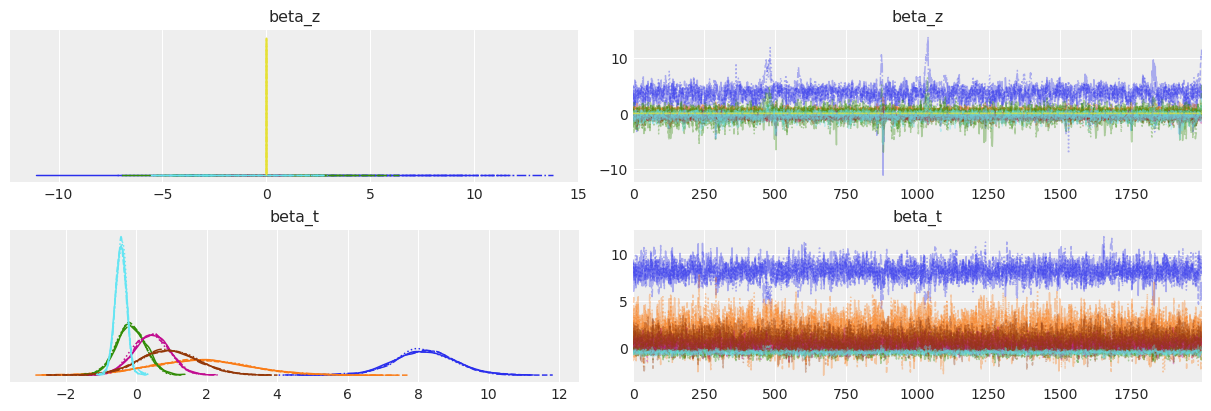

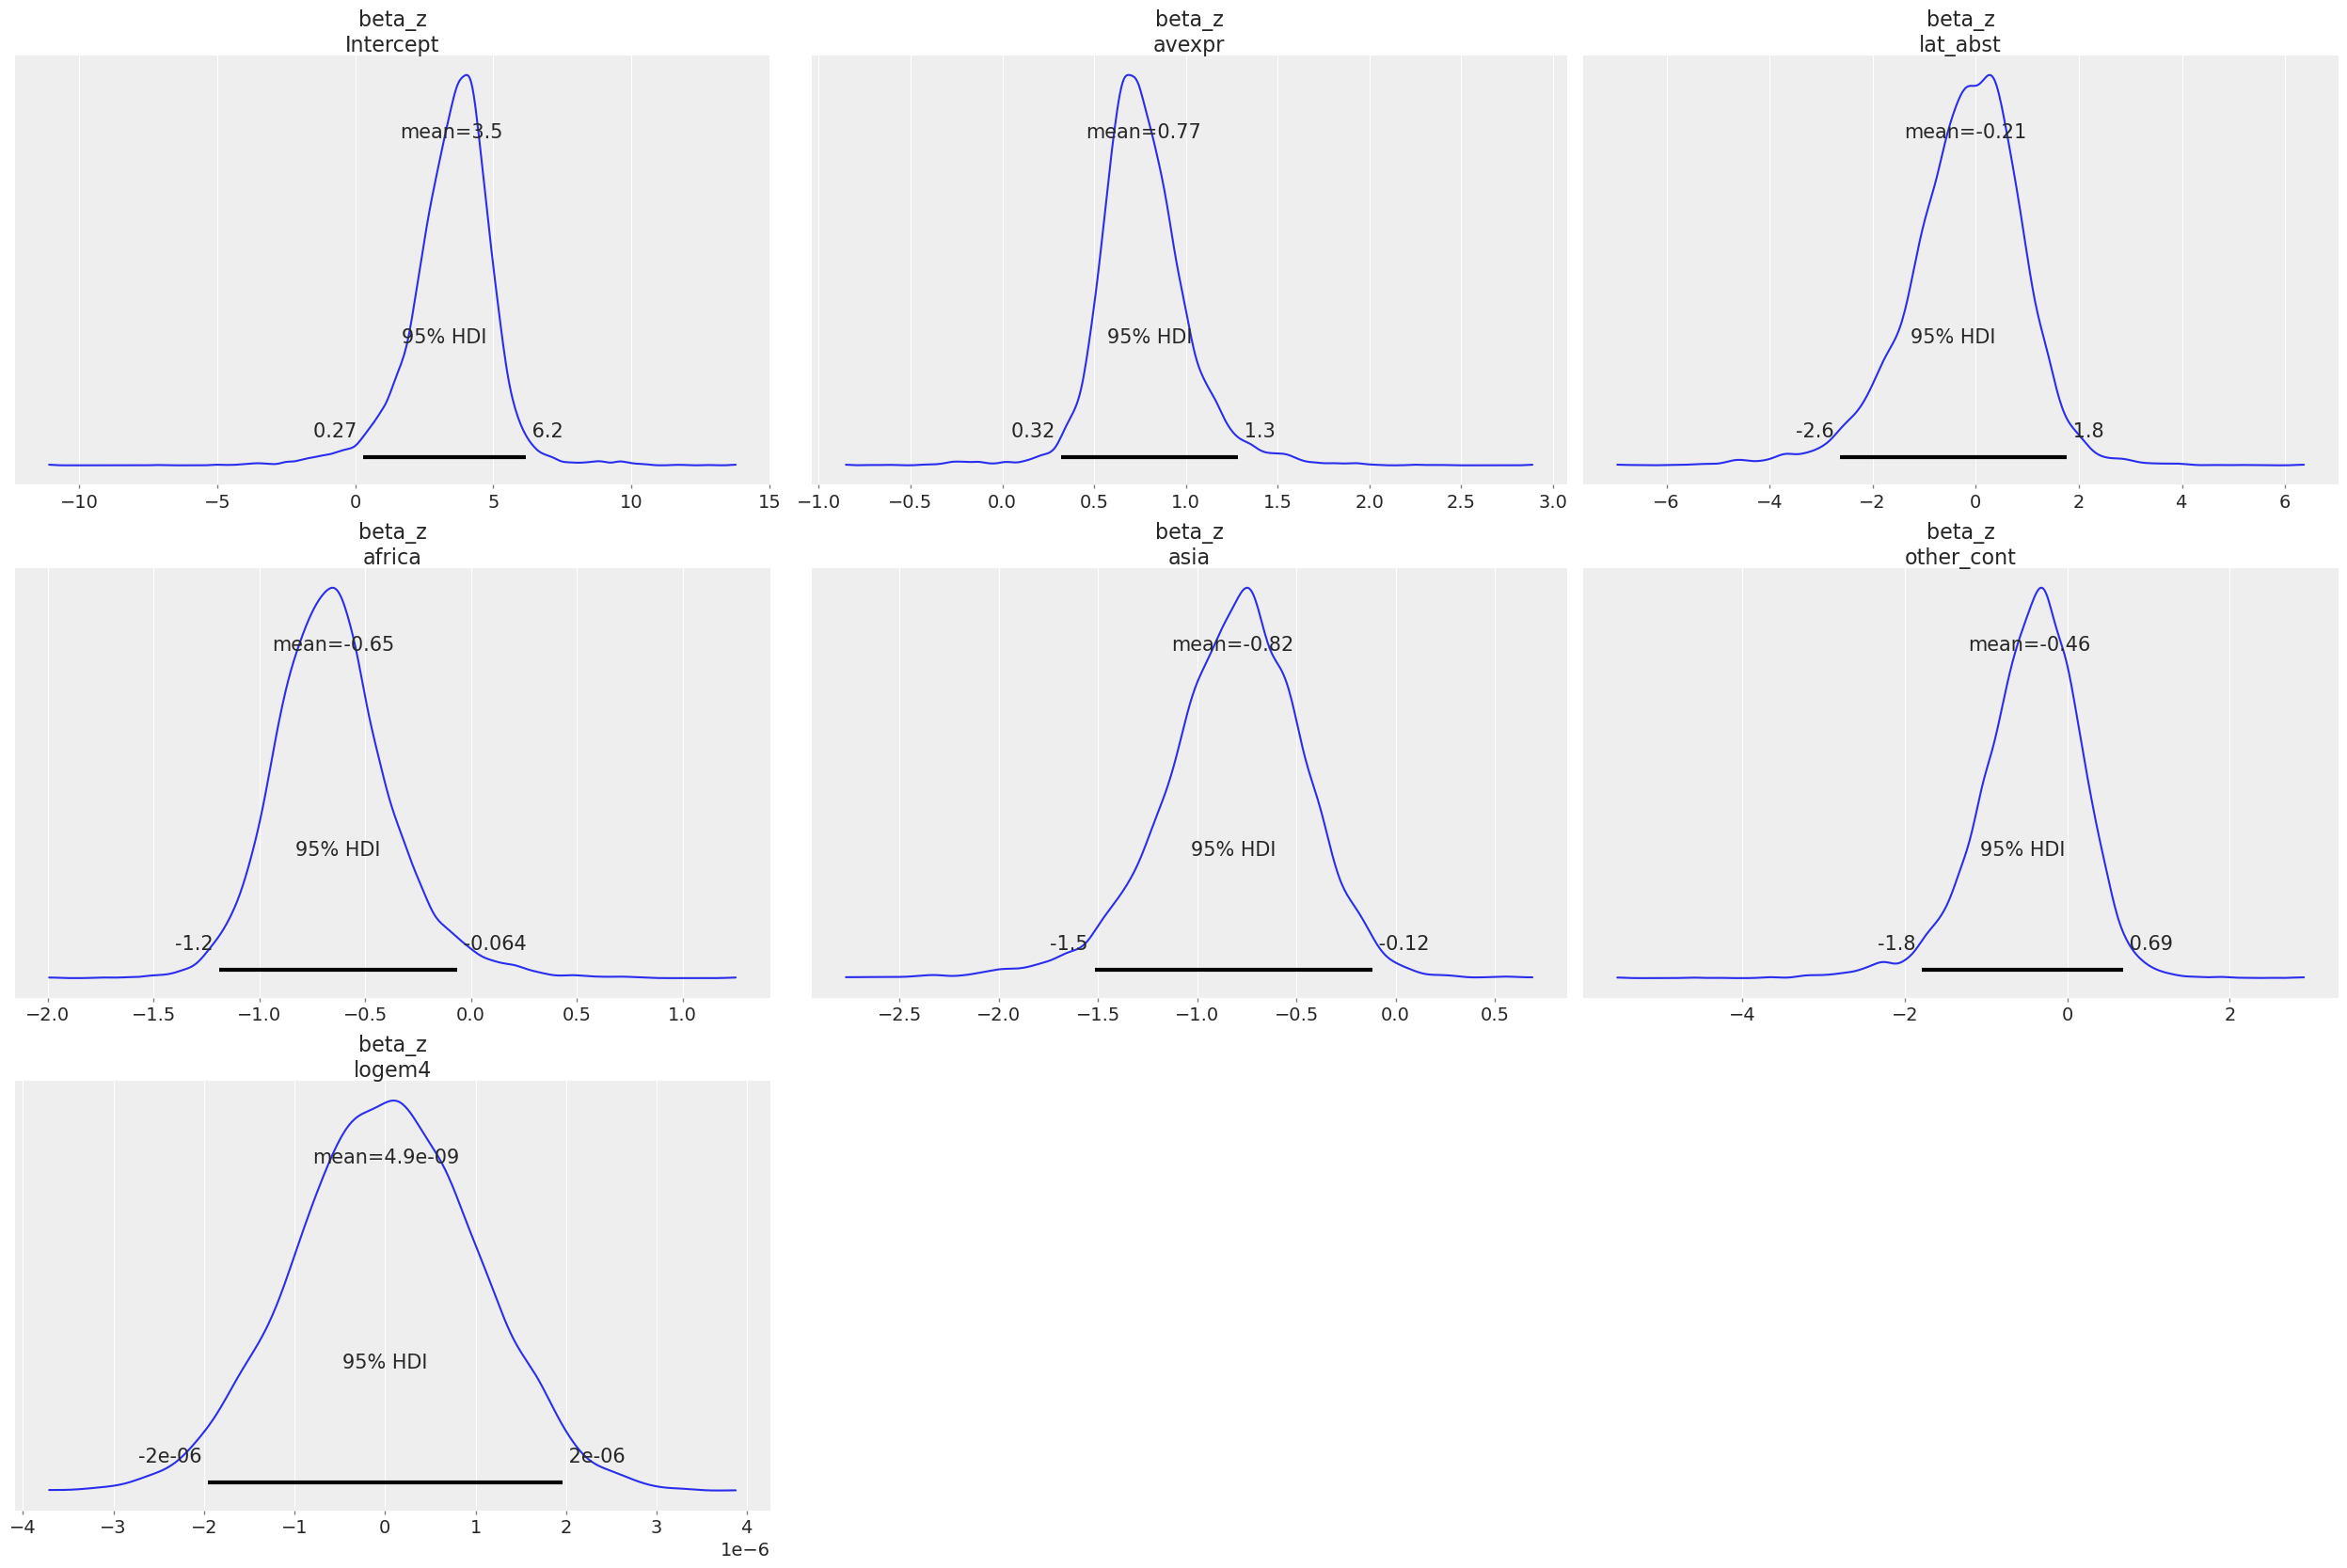

In [4]:
idata2 = az.from_netcdf("ajr_iv_fixdelta_+0.00.nc")
az.plot_trace(idata2, var_names=["beta_z", "beta_t"])
az.plot_posterior(idata2, var_names=["beta_z"], hdi_prob=0.95)


C:\Users\B375471\AppData\Local\Temp\ipykernel_2968\4239290227.py:45: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


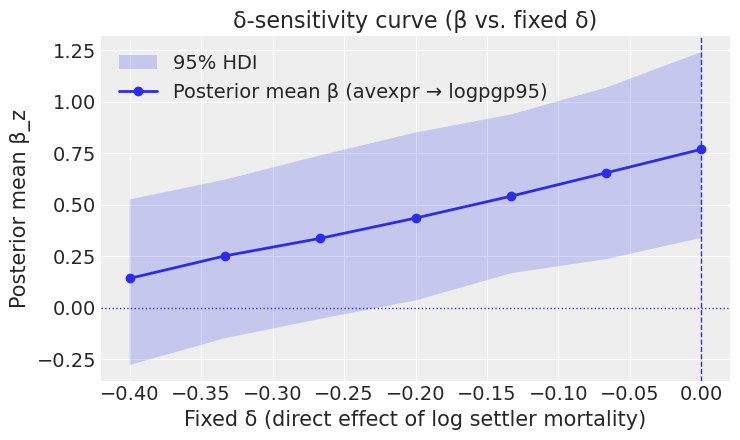

'delta_sensitivity_curve.png'

In [8]:
# Create the delta-sensitivity table from your values, plot the curve with 95% bands,
# and save both the figure and the data for reuse. (Matplotlib only; no seaborn.)

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# ---- 1) Build the DataFrame exactly as provided ------------------------------
data = [
    [-0.400000, -0.071182, 0.143296, -0.276781, 0.526188, 0.000001, "ajr_iv_fixdelta_-0.40.nc"],
    [-0.333333, -0.144307, 0.252496, -0.146972, 0.622847, 0.000001, "ajr_iv_fixdelta_-0.33.nc"],
    [-0.266667, -0.184499, 0.337669, -0.052988, 0.740570, 0.000001, "ajr_iv_fixdelta_-0.27.nc"],
    [-0.200000, -0.240125, 0.436032, 0.036311, 0.851121, 0.000001, "ajr_iv_fixdelta_-0.20.nc"],
    [-0.133333, -0.304144, 0.542127, 0.168078, 0.939133, 0.000001, "ajr_iv_fixdelta_-0.13.nc"],
    [-0.066667, -0.379470, 0.655614, 0.236805, 1.069290, 0.000001, "ajr_iv_fixdelta_-0.07.nc"],
    [ 0.000000, -0.461753, 0.770134, 0.340223, 1.242368, 0.000001, "ajr_iv_fixdelta_+0.00.nc"],
]
cols = ["delta_fixed","delta_actual_mean","avexpr_causal_effect","avexpr_hdi_low","avexpr_hdi_high","delta_sd_used","file"]
df = pd.DataFrame(data, columns=cols)

# Sort by delta_fixed just in case
df = df.sort_values("delta_fixed").reset_index(drop=True)

# ---- 2) Make the delta-sensitivity curve plot --------------------------------
x = df["delta_fixed"].to_numpy()
y = df["avexpr_causal_effect"].to_numpy()
lo = df["avexpr_hdi_low"].to_numpy()
hi = df["avexpr_hdi_high"].to_numpy()

plt.figure(figsize=(7.5, 4.5))
# Credible band
plt.fill_between(x, lo, hi, alpha=0.2, label="95% HDI")
# Mean line
plt.plot(x, y, marker="o", linewidth=2, label="Posterior mean β (avexpr → logpgp95)")

# Reference lines
plt.axvline(0, linestyle="--", linewidth=1)
plt.axhline(0, linestyle=":", linewidth=1)

plt.title("δ-sensitivity curve (β vs. fixed δ)")
plt.xlabel("Fixed δ (direct effect of log settler mortality)")
plt.ylabel("Posterior mean β_z")
plt.legend(loc="best")
plt.tight_layout()

png_path = "delta_sensitivity_curve.png"
plt.savefig(png_path, dpi=160, bbox_inches="tight")
plt.show()

png_path


β_z components: [np.str_('Intercept'), np.str_('avexpr'), np.str_('lat_abst'), np.str_('africa'), np.str_('asia'), np.str_('other_cont'), np.str_('logem4')]
β_t components: [np.str_('Intercept'), np.str_('lat_abst'), np.str_('africa'), np.str_('asia'), np.str_('other_cont'), np.str_('logem4')]


C:\Users\B375471\AppData\Local\Temp\ipykernel_2968\3614373247.py:48: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


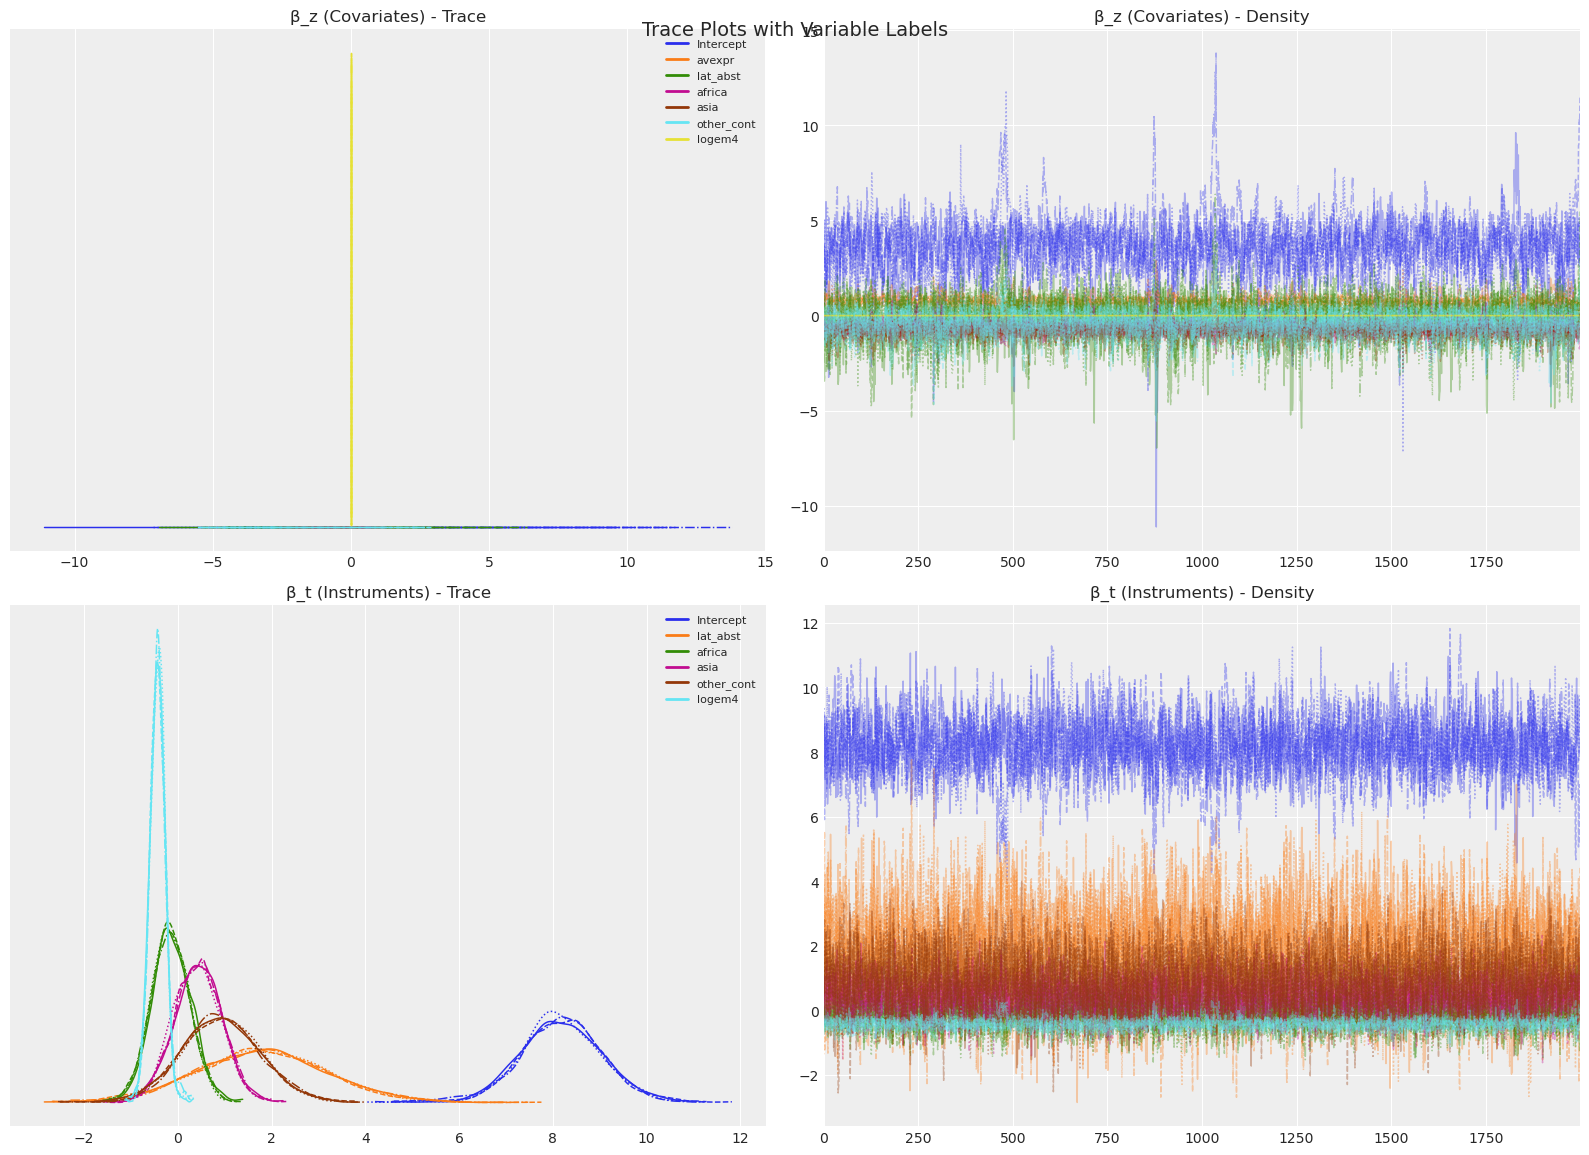

In [5]:
# Same trace plot as above but with variable labels added
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
idata2 = az.from_netcdf("ajr_iv_fixdelta_+0.00.nc")

# Get the coordinate labels
beta_z_coords = list(idata2.posterior.coords['covariates'].values)
beta_t_coords = list(idata2.posterior.coords['instruments'].values)

print("β_z components:", beta_z_coords)
print("β_t components:", beta_t_coords)

# Create the trace plot with enhanced labeling
axes = az.plot_trace(idata2, var_names=["beta_z", "beta_t"], figsize=(16, 12))

# Get the figure and add title
fig = axes.flat[0].figure
fig.suptitle("Trace Plots with Variable Labels", fontsize=14, y=0.95)

# Get default color cycle for mapping
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']

# Add legends to each subplot with color mapping
for i, ax_row in enumerate(axes):
    for j, ax in enumerate(ax_row):
        if j == 0:  # Left column (trace plots)
            if i == 0:  # beta_z
                # Create legend entries for beta_z components
                legend_elements = [plt.Line2D([0], [0], color=colors[k % len(colors)], 
                                            lw=2, label=f'{coord}') 
                                 for k, coord in enumerate(beta_z_coords)]
                ax.legend(handles=legend_elements, loc='upper right', fontsize=8)
                ax.set_title('β_z (Covariates) - Trace', fontsize=12)
            elif i == 1:  # beta_t  
                # Create legend entries for beta_t components
                legend_elements = [plt.Line2D([0], [0], color=colors[k % len(colors)], 
                                            lw=2, label=f'{coord}') 
                                 for k, coord in enumerate(beta_t_coords)]
                ax.legend(handles=legend_elements, loc='upper right', fontsize=8)
                ax.set_title('β_t (Instruments) - Trace', fontsize=12)
        else:  # Right column (density plots)
            if i == 0:
                ax.set_title('β_z (Covariates) - Density', fontsize=12)
            elif i == 1:
                ax.set_title('β_t (Instruments) - Density', fontsize=12)

plt.tight_layout()
plt.show()